In [20]:
import pandas as pd
from datetime import datetime

# Đọc file EconomicFinancialIndicatorsDatabase.csv (bỏ dòng metadata)
df = pd.read_csv('./EconomicFinancialIndicatorsDatabase.csv', skiprows=4)

# Rename columns
df.columns = ['date', 'broad_money', 'policy_rate']

# Parse date từ YYYY-MM format thành YYYY-MM-01
df['date'] = pd.to_datetime(df['date'] + '-01', format='%Y-%m-%d', errors='coerce')

# Loại bỏ dòng không có date
df = df.dropna(subset=['date'])

# Sắp xếp lại chuỗi thời gian tăng dần để đảm bảo tính logic khi điền khuyết
df = df.sort_values('date').reset_index(drop=True)

# Ép kiểu dữ liệu về dạng số để chuẩn bị xử lý điền khuyết
df['broad_money'] = pd.to_numeric(df['broad_money'], errors='coerce')
df['policy_rate'] = pd.to_numeric(df['policy_rate'], errors='coerce')

# Điền khuyết dữ liệu chuỗi thời gian: Dùng giá trị kỳ trước điền cho kỳ sau (Forward Fill)
# Nếu các dòng đầu tiên bị trống, dùng Backward Fill (bfill) để bù nốt dữ liệu ban đầu
df['broad_money'] = df['broad_money'].ffill().bfill()
df['policy_rate'] = df['policy_rate'].ffill().bfill()

# ========== BROAD MONEY TO RESERVES ==========
broad_money_df = df[['date', 'broad_money']].copy()
broad_money_df['indicator'] = 'broad_money'
broad_money_df['value'] = broad_money_df['broad_money'].astype(float)
broad_money_df['unit'] = 'Percent'
broad_money_df['source'] = 'CEIC Database'
broad_money_df['processing_date'] = datetime.now().strftime('%Y-%m-%d')

broad_money_df = broad_money_df[['date', 'indicator', 'value', 'unit', 'source', 'processing_date']]
broad_money_df.to_csv('./raw/broad_money.csv', index=False)
print(f"✓ Saved broad_money.csv: {len(broad_money_df)} rows")
print(broad_money_df.head())

# ========== POLICY RATE ==========
policy_rate_df = df[['date', 'policy_rate']].copy()
policy_rate_df['indicator'] = 'policy_rate'
policy_rate_df['value'] = policy_rate_df['policy_rate'].astype(float)
policy_rate_df['unit'] = 'Percent per annum'
policy_rate_df['source'] = 'CEIC Database'
policy_rate_df['processing_date'] = datetime.now().strftime('%Y-%m-%d')

policy_rate_df = policy_rate_df[['date', 'indicator', 'value', 'unit', 'source', 'processing_date']]
policy_rate_df.to_csv('./raw/policy_rate.csv', index=False)
print(f"\n✓ Saved policy_rate.csv: {len(policy_rate_df)} rows")
print(policy_rate_df.head())

FileNotFoundError: [Errno 2] No such file or directory: './EconomicFinancialIndicatorsDatabase.csv'

In [ ]:
import re
import unicodedata
import pandas as pd

GDP_PATH = "./gdp.csv"
FEATURE_PATH = "./cpi_02_06_selected_variables.csv"
GDP_LAG_Q = 1

def clean_col(s):
    s = unicodedata.normalize("NFKD", str(s)).encode("ascii", "ignore").decode("utf-8")
    s = re.sub(r"[^a-zA-Z0-9]+", "_", s.lower()).strip("_")
    return s

features = pd.read_csv(FEATURE_PATH)
gdp = pd.read_csv(GDP_PATH)

features["date"] = pd.to_datetime(features["date"])
features["quarter_key"] = features["date"].dt.to_period("Q")

gdp = gdp[gdp["type"].isin(["Giá trị hiện hành", "Giá trị so sánh"])].copy()

gdp["quarter_key"] = pd.PeriodIndex(
    year=gdp["year"].astype(int),
    quarter=gdp["quarter"].astype(int),
    freq="Q"
)

gdp_q = (
    gdp.groupby(["quarter_key", "sector", "type"], as_index=False)["value"]
       .sum()
)

gdp_wide = (
    gdp_q.pivot_table(
        index="quarter_key",
        columns=["sector", "type"],
        values="value",
        aggfunc="sum"
    )
)

gdp_wide.columns = [
    "gdp_" + clean_col(col[0]) + "_" + clean_col(col[1])
    for col in gdp_wide.columns
]

gdp_wide = gdp_wide.reset_index()

features_gdp = features.merge(gdp_wide, on="quarter_key", how="left")
features_gdp = features_gdp.drop(columns="quarter_key")

features_gdp.to_csv("features_with_gdp.csv", index=False)

features_gdp.head()

C:\Users\HP\AppData\Local\Temp\ipykernel_20312\965524975.py:22: FutureWarning: Constructing PeriodIndex from fields is deprecated. Use PeriodIndex.from_fields instead.
  gdp["quarter_key"] = pd.PeriodIndex(


,date,cpi_mom,policy_rate,broad_money,ppi_qoq,wti,gasoline_world,gold,policy_rate.1,VNINDEX,NIKKEI225,USDVND,gdp,gdp_cong_nghiep_va_xay_dung_gia_tri_hien_hanh,gdp_cong_nghiep_va_xay_dung_gia_tri_so_sanh,gdp_dich_vu_gia_tri_hien_hanh,gdp_dich_vu_gia_tri_so_sanh,gdp_nong_lam_nghiep_va_thuy_san_gia_tri_hien_hanh,gdp_nong_lam_nghiep_va_thuy_san_gia_tri_so_sanh
0,1995-01-01,103.8,10.8,3.567,-0.73,18.39,0.822,278.299988,10.8,101.55,18649.820312,11039.0,434478.0,NaN,NaN,NaN,NaN,NaN,NaN
1,1995-02-01,103.4,10.8,3.303,-0.73,18.49,0.822,278.299988,10.8,101.55,17053.429688,11050.0,434478.0,NaN,NaN,NaN,NaN,NaN,NaN
2,1995-03-01,100.2,10.8,3.495,-0.73,19.17,0.822,278.299988,10.8,101.55,16139.950195,11045.0,434478.0,NaN,NaN,NaN,NaN,NaN,NaN
3,1995-04-01,101.0,10.8,3.434,-0.73,20.38,0.822,278.299988,10.8,101.55,16806.750000,11041.0,434478.0,NaN,NaN,NaN,NaN,NaN,NaN
4,1995-05-01,101.8,10.8,3.247,-0.73,18.89,0.822,278.299988,10.8,101.55,15436.790039,11045.0,434478.0,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
import re
import unicodedata
import pandas as pd

GDP_PATH = "./gdp.csv"
FEATURE_PATH = "./cpi_02_06_selected_variables.csv"
GDP_LAG_Q = 1

def clean_col(s):
    s = unicodedata.normalize("NFKD", str(s)).encode("ascii", "ignore").decode("utf-8")
    s = re.sub(r"[^a-zA-Z0-9]+", "_", s.lower()).strip("_")
    return s

features = pd.read_csv(FEATURE_PATH)
gdp = pd.read_csv(GDP_PATH)

features["date"] = pd.to_datetime(features["date"])
features["quarter_key"] = features["date"].dt.to_period("Q")

gdp = gdp[gdp["type"].isin(["Giá trị hiện hành", "Giá trị so sánh"])].copy()

gdp["quarter_key"] = pd.PeriodIndex(
    year=gdp["year"].astype(int),
    quarter=gdp["quarter"].astype(int),
    freq="Q"
)

gdp_q = (
    gdp.groupby(["quarter_key", "sector", "type"], as_index=False)["value"]
       .sum()
)

gdp_wide = (
    gdp_q.pivot_table(
        index="quarter_key",
        columns=["sector", "type"],
        values="value",
        aggfunc="sum"
    )
)

gdp_wide.columns = [
    "gdp_" + clean_col(col[0]) + "_" + clean_col(col[1])
    for col in gdp_wide.columns
]

gdp_wide = gdp_wide.reset_index()

features_gdp = features.merge(gdp_wide, on="quarter_key", how="left")
features_gdp = features_gdp.drop(columns="quarter_key")

gdp_cols = [col for col in features_gdp.columns if col.startswith("gdp_")]

features_gdp.index = pd.DatetimeIndex(features_gdp["date"])
features_gdp[gdp_cols] = features_gdp[gdp_cols].interpolate(method="time", limit_direction="both")
features_gdp = features_gdp.reset_index(drop=True)

features_gdp.to_csv("features_with_gdp.csv", index=False)

features_gdp.head()

C:\Users\HP\AppData\Local\Temp\ipykernel_20312\2531448898.py:22: FutureWarning: Constructing PeriodIndex from fields is deprecated. Use PeriodIndex.from_fields instead.
  gdp["quarter_key"] = pd.PeriodIndex(


,date,cpi_mom,policy_rate,broad_money,ppi_qoq,wti,gasoline_world,gold,policy_rate.1,VNINDEX,NIKKEI225,USDVND,gdp,gdp_cong_nghiep_va_xay_dung_gia_tri_hien_hanh,gdp_cong_nghiep_va_xay_dung_gia_tri_so_sanh,gdp_dich_vu_gia_tri_hien_hanh,gdp_dich_vu_gia_tri_so_sanh,gdp_nong_lam_nghiep_va_thuy_san_gia_tri_hien_hanh,gdp_nong_lam_nghiep_va_thuy_san_gia_tri_so_sanh
0,1995-01-01,103.8,10.8,3.567,-0.73,18.39,0.822,278.299988,10.8,101.55,18649.820312,11039.0,434478.0,190166.0,47216.0,183733.0,49573.0,243666.784335,43349.773005
1,1995-02-01,103.4,10.8,3.303,-0.73,18.49,0.822,278.299988,10.8,101.55,17053.429688,11050.0,434478.0,190166.0,47216.0,183733.0,49573.0,243666.784335,43349.773005
2,1995-03-01,100.2,10.8,3.495,-0.73,19.17,0.822,278.299988,10.8,101.55,16139.950195,11045.0,434478.0,190166.0,47216.0,183733.0,49573.0,243666.784335,43349.773005
3,1995-04-01,101.0,10.8,3.434,-0.73,20.38,0.822,278.299988,10.8,101.55,16806.750000,11041.0,434478.0,190166.0,47216.0,183733.0,49573.0,243666.784335,43349.773005
4,1995-05-01,101.8,10.8,3.247,-0.73,18.89,0.822,278.299988,10.8,101.55,15436.790039,11045.0,434478.0,190166.0,47216.0,183733.0,49573.0,243666.784335,43349.773005


In [6]:
features_gdp.tail()

,date,cpi_mom,policy_rate,broad_money,ppi_qoq,wti,gasoline_world,gold,policy_rate.1,VNINDEX,NIKKEI225,USDVND,gdp,gdp_cong_nghiep_va_xay_dung_gia_tri_hien_hanh,gdp_cong_nghiep_va_xay_dung_gia_tri_so_sanh,gdp_dich_vu_gia_tri_hien_hanh,gdp_dich_vu_gia_tri_so_sanh,gdp_nong_lam_nghiep_va_thuy_san_gia_tri_hien_hanh,gdp_nong_lam_nghiep_va_thuy_san_gia_tri_so_sanh
355,2024-08-01,100.00,4.5,6.576,0.07,72.65,2.0125,2493.800049,4.5,1283.87,38647.750000,24860.0,3.757535e+06,1.092321e+06,587190.213321,1.424118e+06,812351.865986,333469.455723,162421.009421
356,2024-09-01,100.29,4.5,6.576,0.07,67.77,1.9525,2636.100098,4.5,1287.94,37919.550781,24555.0,3.757535e+06,1.092321e+06,587190.213321,1.424118e+06,812351.865986,333469.455723,162421.009421
357,2024-10-01,100.33,4.5,6.576,-0.23,68.81,1.9568,2738.300049,4.5,1264.48,39081.250000,25270.0,4.320246e+06,1.092321e+06,587190.213321,1.424118e+06,812351.865986,333469.455723,162421.009421
358,2024-11-01,100.13,4.5,6.576,-0.23,67.72,1.9858,2657.000000,4.5,1250.46,38208.031250,25344.0,4.320246e+06,1.092321e+06,587190.213321,1.424118e+06,812351.865986,333469.455723,162421.009421
359,2024-12-01,100.29,4.5,6.576,-0.23,71.25,1.9885,2629.199951,4.5,1266.78,39894.539062,25480.0,4.320246e+06,1.092321e+06,587190.213321,1.424118e+06,812351.865986,333469.455723,162421.009421


In [ ]:
# gdp_cols = [c for c in features_gdp.columns if c.startswith("gdp_")]

# features_gdp = features_gdp.sort_values("date")
# features_gdp[gdp_cols] = features_gdp[gdp_cols].ffill()
# features_gdp = features_gdp.dropna(subset=gdp_cols).reset_index(drop=True)

In [7]:

features_gdp.head()

,date,cpi_mom,policy_rate,broad_money,ppi_qoq,wti,gasoline_world,gold,policy_rate.1,VNINDEX,NIKKEI225,USDVND,gdp,gdp_cong_nghiep_va_xay_dung_gia_tri_hien_hanh,gdp_cong_nghiep_va_xay_dung_gia_tri_so_sanh,gdp_dich_vu_gia_tri_hien_hanh,gdp_dich_vu_gia_tri_so_sanh,gdp_nong_lam_nghiep_va_thuy_san_gia_tri_hien_hanh,gdp_nong_lam_nghiep_va_thuy_san_gia_tri_so_sanh
0,1995-01-01,103.8,10.8,3.567,-0.73,18.39,0.822,278.299988,10.8,101.55,18649.820312,11039.0,434478.0,190166.0,47216.0,183733.0,49573.0,243666.784335,43349.773005
1,1995-02-01,103.4,10.8,3.303,-0.73,18.49,0.822,278.299988,10.8,101.55,17053.429688,11050.0,434478.0,190166.0,47216.0,183733.0,49573.0,243666.784335,43349.773005
2,1995-03-01,100.2,10.8,3.495,-0.73,19.17,0.822,278.299988,10.8,101.55,16139.950195,11045.0,434478.0,190166.0,47216.0,183733.0,49573.0,243666.784335,43349.773005
3,1995-04-01,101.0,10.8,3.434,-0.73,20.38,0.822,278.299988,10.8,101.55,16806.750000,11041.0,434478.0,190166.0,47216.0,183733.0,49573.0,243666.784335,43349.773005
4,1995-05-01,101.8,10.8,3.247,-0.73,18.89,0.822,278.299988,10.8,101.55,15436.790039,11045.0,434478.0,190166.0,47216.0,183733.0,49573.0,243666.784335,43349.773005


In [8]:

features_gdp.tail()

,date,cpi_mom,policy_rate,broad_money,ppi_qoq,wti,gasoline_world,gold,policy_rate.1,VNINDEX,NIKKEI225,USDVND,gdp,gdp_cong_nghiep_va_xay_dung_gia_tri_hien_hanh,gdp_cong_nghiep_va_xay_dung_gia_tri_so_sanh,gdp_dich_vu_gia_tri_hien_hanh,gdp_dich_vu_gia_tri_so_sanh,gdp_nong_lam_nghiep_va_thuy_san_gia_tri_hien_hanh,gdp_nong_lam_nghiep_va_thuy_san_gia_tri_so_sanh
355,2024-08-01,100.00,4.5,6.576,0.07,72.65,2.0125,2493.800049,4.5,1283.87,38647.750000,24860.0,3.757535e+06,1.092321e+06,587190.213321,1.424118e+06,812351.865986,333469.455723,162421.009421
356,2024-09-01,100.29,4.5,6.576,0.07,67.77,1.9525,2636.100098,4.5,1287.94,37919.550781,24555.0,3.757535e+06,1.092321e+06,587190.213321,1.424118e+06,812351.865986,333469.455723,162421.009421
357,2024-10-01,100.33,4.5,6.576,-0.23,68.81,1.9568,2738.300049,4.5,1264.48,39081.250000,25270.0,4.320246e+06,1.092321e+06,587190.213321,1.424118e+06,812351.865986,333469.455723,162421.009421
358,2024-11-01,100.13,4.5,6.576,-0.23,67.72,1.9858,2657.000000,4.5,1250.46,38208.031250,25344.0,4.320246e+06,1.092321e+06,587190.213321,1.424118e+06,812351.865986,333469.455723,162421.009421
359,2024-12-01,100.29,4.5,6.576,-0.23,71.25,1.9885,2629.199951,4.5,1266.78,39894.539062,25480.0,4.320246e+06,1.092321e+06,587190.213321,1.424118e+06,812351.865986,333469.455723,162421.009421


In [10]:
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.api import VAR
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [11]:

warnings.filterwarnings("ignore")

TARGET = "cpi_mom"

TEST_SIZE = 0.15
LAG = 3
EPOCHS = 300
LR = 1e-3
BATCH_SIZE = 32
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

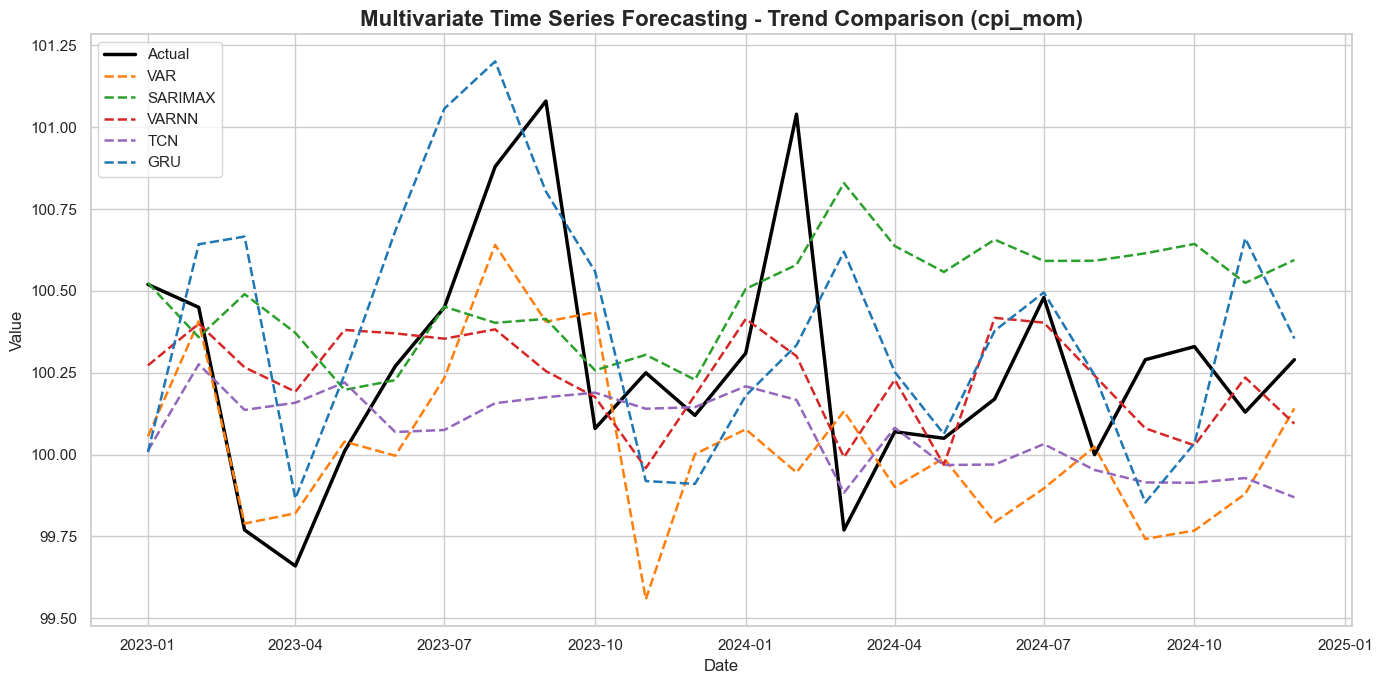

,model,rmse,mae,r2
0,VARNN,0.336909,0.264535,0.088321
1,TCN,0.399292,0.312215,-0.280554
2,VAR,0.412974,0.320611,-0.369818
3,GRU,0.420287,0.348108,-0.418759
4,SARIMAX,0.446953,0.356885,-0.604500


In [14]:
import re
import unicodedata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

GDP_PATH = "./gdp.csv"
FEATURE_PATH = "./cpi_02_06_selected_variables.csv"
GDP_LAG_Q = 1

def clean_col(s):
    s = unicodedata.normalize("NFKD", str(s)).encode("ascii", "ignore").decode("utf-8")
    s = re.sub(r"[^a-zA-Z0-9]+", "_", s.lower()).strip("_")
    return s

features = pd.read_csv(FEATURE_PATH)
gdp = pd.read_csv(GDP_PATH)

features["date"] = pd.to_datetime(features["date"])
features["quarter_key"] = features["date"].dt.to_period("Q")

gdp = gdp[gdp["type"].isin(["Giá trị hiện hành", "Giá trị so sánh"])].copy()

gdp["quarter_key"] = pd.PeriodIndex(
    year=gdp["year"].astype(int),
    quarter=gdp["quarter"].astype(int),
    freq="Q"
)

gdp_q = (
    gdp.groupby(["quarter_key", "sector", "type"], as_index=False)["value"]
       .sum()
)

gdp_wide = (
    gdp_q.pivot_table(
        index="quarter_key",
        columns=["sector", "type"],
        values="value",
        aggfunc="sum"
    )
)

gdp_wide.columns = [
    "gdp_" + clean_col(col[0]) + "_" + clean_col(col[1])
    for col in gdp_wide.columns
]

gdp_wide = gdp_wide.reset_index()

features_gdp = features.merge(gdp_wide, on="quarter_key", how="left")
features_gdp = features_gdp.drop(columns="quarter_key")

def metrics(y_true, y_pred):
    y_true = pd.Series(y_true).dropna()
    y_pred = pd.Series(y_pred).dropna()
    idx = y_true.index.intersection(y_pred.index)

    y_true = y_true.loc[idx]
    y_pred = y_pred.loc[idx]

    return {
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred)
    }


def load_data(target):
    df = features_gdp.copy()

    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").set_index("date")

    df = df.loc[:, ~df.columns.duplicated()]
    df = df.select_dtypes(include=[np.number])
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.ffill().dropna()

    if "policy_rate.1" in df.columns:
        df = df.drop(columns=["policy_rate.1"])

    selected_cols = [
        target,
        "policy_rate",
        "broad_money",
        "ppi_qoq",
        "wti",
        "gasoline_world",
        "gold",
        "VNINDEX",
        "NIKKEI225",
        "USDVND",
        "gdp_cong_nghiep_va_xay_dung_gia_tri_hien_hanh",
        
        "gdp_dich_vu_gia_tri_hien_hanh",
        
        "gdp_nong_lam_nghiep_va_thuy_san_gia_tri_hien_hanh"
    ]

    selected_cols = [c for c in selected_cols if c in df.columns]
    df = df[selected_cols].copy()

    y = df[target].copy()
    X = df.drop(columns=[target]).copy()

    return df, y, X


def split_time(data, test_size):
    n_test = max(1, int(len(data) * test_size))
    return data.iloc[:-n_test].copy(), data.iloc[-n_test:].copy()


def train_var(df, target):
    train, test = split_time(df, TEST_SIZE)

    scaler = StandardScaler()
    train_s = pd.DataFrame(scaler.fit_transform(train), index=train.index, columns=train.columns)
    full_s = pd.DataFrame(scaler.transform(df), index=df.index, columns=df.columns)

    max_lag = min(LAG, max(1, len(train) // (df.shape[1] * 3)))
    res = VAR(train_s).fit(maxlags=max_lag, ic=None)

    preds = []
    target_idx = df.columns.get_loc(target)

    for i in range(len(test)):
        pos = len(train) + i
        history = full_s.iloc[pos - res.k_ar:pos].values
        pred_s = res.forecast(history, steps=1)

        pred = scaler.inverse_transform(pred_s)[0, target_idx]
        preds.append(pred)

    return pd.Series(preds, index=test.index, name="VAR")


def train_sarimax(y, X, target):
    train_y_df, test_y_df = split_time(y.to_frame(name=target), TEST_SIZE)

    train_y = train_y_df[target]
    test_y = test_y_df[target]

    train_X = X.loc[train_y.index]
    test_X = X.loc[test_y.index]

    x_scaler = StandardScaler()
    train_X_s = x_scaler.fit_transform(train_X)
    test_X_s = x_scaler.transform(test_X)

    model = SARIMAX(
        train_y,
        exog=train_X_s,
        order=(1, 0, 1),
        seasonal_order=(0, 0, 0, 0),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    res = model.fit(disp=False)
    pred = res.forecast(steps=len(test_y), exog=test_X_s)
    pred.index = test_y.index
    pred.name = "SARIMAX"

    return pred


def make_lag_data(df, target, lag):
    values = df.values
    target_idx = df.columns.get_loc(target)

    X, y, idx = [], [], []

    for i in range(lag, len(df)):
        X.append(values[i - lag:i])
        y.append(values[i, target_idx])
        idx.append(df.index[i])

    return np.array(X), np.array(y), pd.Index(idx)


class VARNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = x.reshape(x.size(0), -1)
        return self.net(x).squeeze(-1)


class GRUModel(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.gru = nn.GRU(
            input_size=n_features,
            hidden_size=64,
            num_layers=1,
            batch_first=True
        )
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :]).squeeze(-1)


def train_torch_model(df, target, model_type):
    train, test = split_time(df, TEST_SIZE)

    scaler = StandardScaler()
    train_s = pd.DataFrame(scaler.fit_transform(train), index=train.index, columns=train.columns)
    full_s = pd.DataFrame(scaler.transform(df), index=df.index, columns=df.columns)

    X_all, y_all, idx_all = make_lag_data(full_s, target, LAG)

    train_mask = idx_all.isin(train.index)
    test_mask = idx_all.isin(test.index)

    X_train = torch.tensor(X_all[train_mask], dtype=torch.float32)
    y_train = torch.tensor(y_all[train_mask], dtype=torch.float32)
    X_test = torch.tensor(X_all[test_mask], dtype=torch.float32)

    idx_test = idx_all[test_mask]

    if model_type == "GRU":
        model = GRUModel(df.shape[1])
    else:
        model = VARNN(LAG * df.shape[1])

    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    loss_fn = nn.SmoothL1Loss()

    dataset = torch.utils.data.TensorDataset(X_train, y_train)
    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=min(BATCH_SIZE, len(dataset)),
        shuffle=False
    )

    model.train()

    for _ in range(EPOCHS):
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()

    model.eval()

    with torch.no_grad():
        pred_s = model(X_test).numpy()

    target_idx = df.columns.get_loc(target)
    dummy = np.zeros((len(pred_s), df.shape[1]))
    dummy[:, target_idx] = pred_s

    pred = scaler.inverse_transform(dummy)[:, target_idx]

    return pd.Series(pred, index=idx_test, name=model_type)


df, y, X = load_data(TARGET)

train_df, test_df = split_time(df, TEST_SIZE)
test_y = test_df[TARGET]

preds = {}

try:
    preds["VAR"] = train_var(df, TARGET)
except Exception as e:
    print("VAR lỗi:", e)

try:
    preds["SARIMAX"] = train_sarimax(y, X, TARGET)
except Exception as e:
    print("SARIMAX lỗi:", e)

try:
    preds["VARNN"] = train_torch_model(df, TARGET, "VARNN")
except Exception as e:
    print("VARNN lỗi:", e)
try:
    preds["TCN"] = train_torch_model(df, TARGET, "TCN")
except Exception as e:
    print("TCN lỗi:", e)

try:
    preds["GRU"] = train_torch_model(df, TARGET, "GRU")
except Exception as e:
    print("GRU lỗi:", e)

results = []

for name, pred in preds.items():
    idx = test_y.index.intersection(pred.index)

    if len(idx) == 0:
        continue

    m = metrics(test_y.loc[idx], pred.loc[idx])

    results.append({
        "model": name,
        "rmse": m["rmse"],
        "mae": m["mae"],
        "r2": m["r2"]
    })

result_df = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)

forecast_df = pd.DataFrame({"actual": test_y})

for name, pred in preds.items():
    forecast_df[name] = pred

plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

plt.plot(forecast_df.index, forecast_df["actual"], label="Actual", color="black", linewidth=2.5, linestyle="-")

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
for i, col in enumerate(forecast_df.columns):
    if col != "actual" and col in preds:
        plt.plot(forecast_df.index, forecast_df[col], label=col, color=colors[i % len(colors)], linewidth=1.8, linestyle="--")

plt.title(f"Multivariate Time Series Forecasting - Trend Comparison ({TARGET})", fontsize=16, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Value", fontsize=12)
plt.legend(loc="upper left", frameon=True, fontsize=11)
plt.tight_layout()
plt.show()

result_df

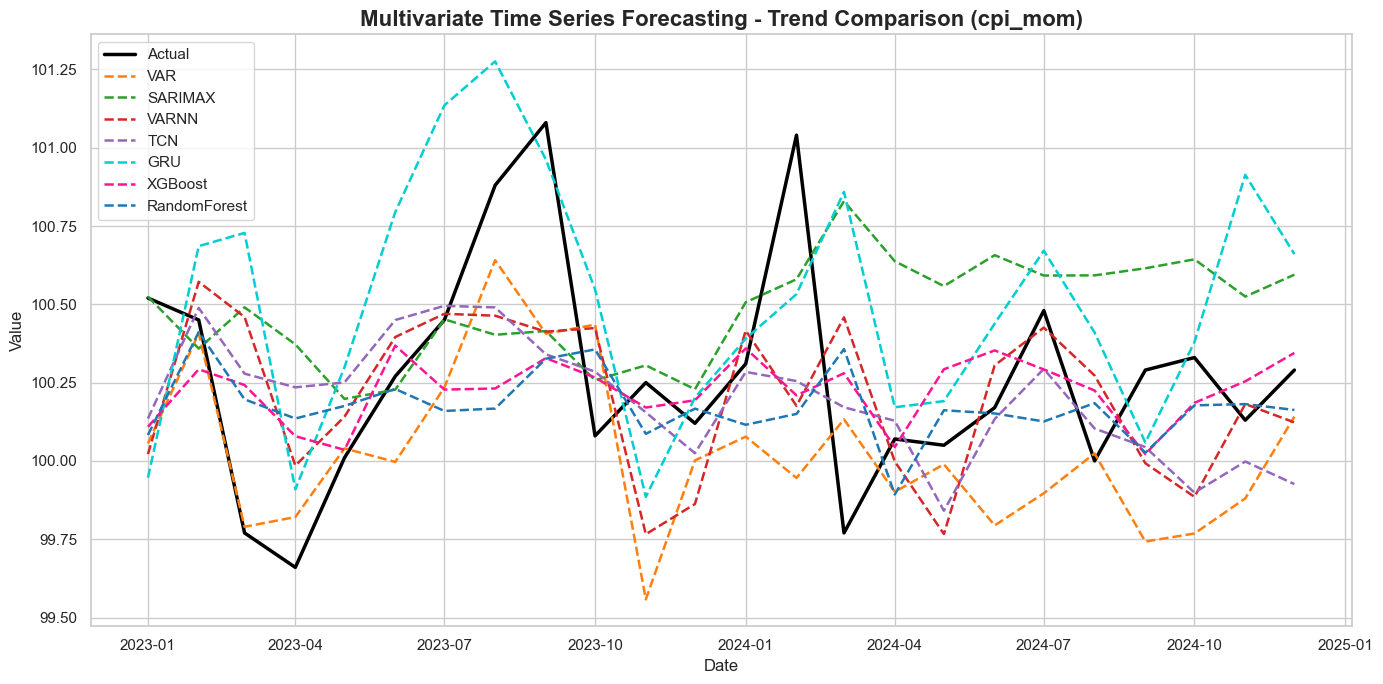

,model,rmse,mae,r2
0,TCN,0.345106,0.269812,0.043420
1,XGBoost,0.349234,0.266287,0.020400
2,RandomForest,0.375583,0.289169,-0.132998
3,VARNN,0.389724,0.313217,-0.219916
4,VAR,0.412974,0.320611,-0.369818
5,SARIMAX,0.446953,0.356885,-0.604500
6,GRU,0.469279,0.381949,-0.768801


In [18]:
import re
import unicodedata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

GDP_PATH = "./gdp.csv"
FEATURE_PATH = "./cpi_02_06_selected_variables.csv"
GDP_LAG_Q = 1

def clean_col(s):
    s = unicodedata.normalize("NFKD", str(s)).encode("ascii", "ignore").decode("utf-8")
    s = re.sub(r"[^a-zA-Z0-9]+", "_", s.lower()).strip("_")
    return s

features = pd.read_csv(FEATURE_PATH)
gdp = pd.read_csv(GDP_PATH)

features["date"] = pd.to_datetime(features["date"])
features["quarter_key"] = features["date"].dt.to_period("Q")

gdp = gdp[gdp["type"].isin(["Giá trị hiện hành", "Giá trị so sánh"])].copy()

gdp["quarter_key"] = pd.PeriodIndex(
    year=gdp["year"].astype(int),
    quarter=gdp["quarter"].astype(int),
    freq="Q"
)

gdp_q = (
    gdp.groupby(["quarter_key", "sector", "type"], as_index=False)["value"]
       .sum()
)

gdp_wide = (
    gdp_q.pivot_table(
        index="quarter_key",
        columns=["sector", "type"],
        values="value",
        aggfunc="sum"
    )
)

gdp_wide.columns = [
    "gdp_" + clean_col(col[0]) + "_" + clean_col(col[1])
    for col in gdp_wide.columns
]

gdp_wide = gdp_wide.reset_index()

features_gdp = features.merge(gdp_wide, on="quarter_key", how="left")
features_gdp = features_gdp.drop(columns="quarter_key")

def metrics(y_true, y_pred):
    y_true = pd.Series(y_true).dropna()
    y_pred = pd.Series(y_pred).dropna()
    idx = y_true.index.intersection(y_pred.index)

    y_true = y_true.loc[idx]
    y_pred = y_pred.loc[idx]

    return {
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred)
    }


def load_data(target):
    df = features_gdp.copy()

    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").set_index("date")

    df = df.loc[:, ~df.columns.duplicated()]
    df = df.select_dtypes(include=[np.number])
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.ffill().dropna()

    if "policy_rate.1" in df.columns:
        df = df.drop(columns=["policy_rate.1"])

    selected_cols = [
        target,
        "policy_rate",
        "broad_money",
        "ppi_qoq",
        "wti",
        "gasoline_world",
        "gold",
        "VNINDEX",
        "NIKKEI225",
        "USDVND",
        "gdp_cong_nghiep_va_xay_dung_gia_tri_hien_hanh",
        "gdp_dich_vu_gia_tri_hien_hanh",
        "gdp_nong_lam_nghiep_va_thuy_san_gia_tri_hien_hanh"
    ]

    selected_cols = [c for c in selected_cols if c in df.columns]
    df = df[selected_cols].copy()

    y = df[target].copy()
    X = df.drop(columns=[target]).copy()

    return df, y, X


def split_time(data, test_size):
    n_test = max(1, int(len(data) * test_size))
    return data.iloc[:-n_test].copy(), data.iloc[-n_test:].copy()


def train_var(df, target):
    train, test = split_time(df, TEST_SIZE)

    scaler = StandardScaler()
    train_s = pd.DataFrame(scaler.fit_transform(train), index=train.index, columns=train.columns)
    full_s = pd.DataFrame(scaler.transform(df), index=df.index, columns=df.columns)

    max_lag = min(LAG, max(1, len(train) // (df.shape[1] * 3)))
    res = VAR(train_s).fit(maxlags=max_lag, ic=None)

    preds = []
    target_idx = df.columns.get_loc(target)

    for i in range(len(test)):
        pos = len(train) + i
        history = full_s.iloc[pos - res.k_ar:pos].values
        pred_s = res.forecast(history, steps=1)

        pred = scaler.inverse_transform(pred_s)[0, target_idx]
        preds.append(pred)

    return pd.Series(preds, index=test.index, name="VAR")


def train_sarimax(y, X, target):
    train_y_df, test_y_df = split_time(y.to_frame(name=target), TEST_SIZE)

    train_y = train_y_df[target]
    test_y = test_y_df[target]

    train_X = X.loc[train_y.index]
    test_X = X.loc[test_y.index]

    x_scaler = StandardScaler()
    train_X_s = x_scaler.fit_transform(train_X)
    test_X_s = x_scaler.transform(test_X)

    model = SARIMAX(
        train_y,
        exog=train_X_s,
        order=(1, 0, 1),
        seasonal_order=(0, 0, 0, 0),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    res = model.fit(disp=False)
    pred = res.forecast(steps=len(test_y), exog=test_X_s)
    pred.index = test_y.index
    pred.name = "SARIMAX"

    return pred


def make_lag_data(df, target, lag):
    values = df.values
    target_idx = df.columns.get_loc(target)

    X, y, idx = [], [], []

    for i in range(lag, len(df)):
        X.append(values[i - lag:i])
        y.append(values[i, target_idx])
        idx.append(df.index[i])

    return np.array(X), np.array(y), pd.Index(idx)


class VARNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = x.reshape(x.size(0), -1)
        return self.net(x).squeeze(-1)


class GRUModel(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.gru = nn.GRU(
            input_size=n_features,
            hidden_size=64,
            num_layers=1,
            batch_first=True
        )
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :]).squeeze(-1)


def train_torch_model(df, target, model_type):
    train, test = split_time(df, TEST_SIZE)

    scaler = StandardScaler()
    train_s = pd.DataFrame(scaler.fit_transform(train), index=train.index, columns=train.columns)
    full_s = pd.DataFrame(scaler.transform(df), index=df.index, columns=df.columns)

    X_all, y_all, idx_all = make_lag_data(full_s, target, LAG)

    train_mask = idx_all.isin(train.index)
    test_mask = idx_all.isin(test.index)

    X_train = torch.tensor(X_all[train_mask], dtype=torch.float32)
    y_train = torch.tensor(y_all[train_mask], dtype=torch.float32)
    X_test = torch.tensor(X_all[test_mask], dtype=torch.float32)

    idx_test = idx_all[test_mask]

    if model_type == "GRU":
        model = GRUModel(df.shape[1])
    else:
        model = VARNN(LAG * df.shape[1])

    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    loss_fn = nn.SmoothL1Loss()

    dataset = torch.utils.data.TensorDataset(X_train, y_train)
    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=min(BATCH_SIZE, len(dataset)),
        shuffle=False
    )

    model.train()

    for _ in range(EPOCHS):
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()

    model.eval()

    with torch.no_grad():
        pred_s = model(X_test).numpy()

    target_idx = df.columns.get_loc(target)
    dummy = np.zeros((len(pred_s), df.shape[1]))
    dummy[:, target_idx] = pred_s

    pred = scaler.inverse_transform(dummy)[:, target_idx]

    return pd.Series(pred, index=idx_test, name=model_type)


def train_sklearn_tree_model(df, target, model_type):
    train, test = split_time(df, TEST_SIZE)

    scaler = StandardScaler()
    train_s = pd.DataFrame(scaler.fit_transform(train), index=train.index, columns=train.columns)
    full_s = pd.DataFrame(scaler.transform(df), index=df.index, columns=df.columns)

    X_all, y_all, idx_all = make_lag_data(full_s, target, LAG)
    X_all_flat = X_all.reshape(X_all.shape[0], -1)

    train_mask = idx_all.isin(train.index)
    test_mask = idx_all.isin(test.index)

    X_train = X_all_flat[train_mask]
    y_train = y_all[train_mask]
    X_test = X_all_flat[test_mask]
    idx_test = idx_all[test_mask]

    if model_type == "XGBoost":
        model = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.05, random_state=42)
    else:
        model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)

    model.fit(X_train, y_train)
    pred_s = model.predict(X_test)

    target_idx = df.columns.get_loc(target)
    dummy = np.zeros((len(pred_s), df.shape[1]))
    dummy[:, target_idx] = pred_s

    pred = scaler.inverse_transform(dummy)[:, target_idx]

    return pd.Series(pred, index=idx_test, name=model_type)


df, y, X = load_data(TARGET)

train_df, test_df = split_time(df, TEST_SIZE)
test_y = test_df[TARGET]

preds = {}

try:
    preds["VAR"] = train_var(df, TARGET)
except Exception as e:
    print("VAR lỗi:", e)

try:
    preds["SARIMAX"] = train_sarimax(y, X, TARGET)
except Exception as e:
    print("SARIMAX lỗi:", e)

try:
    preds["VARNN"] = train_torch_model(df, TARGET, "VARNN")
except Exception as e:
    print("VARNN lỗi:", e)
try:
    preds["TCN"] = train_torch_model(df, TARGET, "TCN")
except Exception as e:
    print("TCN lỗi:", e)

try:
    preds["GRU"] = train_torch_model(df, TARGET, "GRU")
except Exception as e:
    print("GRU lỗi:", e)

try:
    preds["XGBoost"] = train_sklearn_tree_model(df, TARGET, "XGBoost")
except Exception as e:
    print("XGBoost lỗi:", e)

try:
    preds["RandomForest"] = train_sklearn_tree_model(df, TARGET, "RandomForest")
except Exception as e:
    print("RandomForest lỗi:", e)

results = []

for name, pred in preds.items():
    idx = test_y.index.intersection(pred.index)

    if len(idx) == 0:
        continue

    m = metrics(test_y.loc[idx], pred.loc[idx])

    results.append({
        "model": name,
        "rmse": m["rmse"],
        "mae": m["mae"],
        "r2": m["r2"]
    })

result_df = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)

forecast_df = pd.DataFrame({"actual": test_y})

for name, pred in preds.items():
    forecast_df[name] = pred

plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

plt.plot(forecast_df.index, forecast_df["actual"], label="Actual", color="black", linewidth=2.5, linestyle="-")

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#00ced1", "#ff1493"]
for i, col in enumerate(forecast_df.columns):
    if col != "actual" and col in preds:
        plt.plot(forecast_df.index, forecast_df[col], label=col, color=colors[i % len(colors)], linewidth=1.8, linestyle="--")

plt.title(f"Multivariate Time Series Forecasting - Trend Comparison ({TARGET})", fontsize=16, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Value", fontsize=12)
plt.legend(loc="upper left", frameon=True, fontsize=11)
plt.tight_layout()
plt.show()

result_df

--- TCN OPTIMIZED METRICS ---
RMSE: 0.365553
MAE : 0.293180
R2  : -0.219117
MAPE: 0.292279%


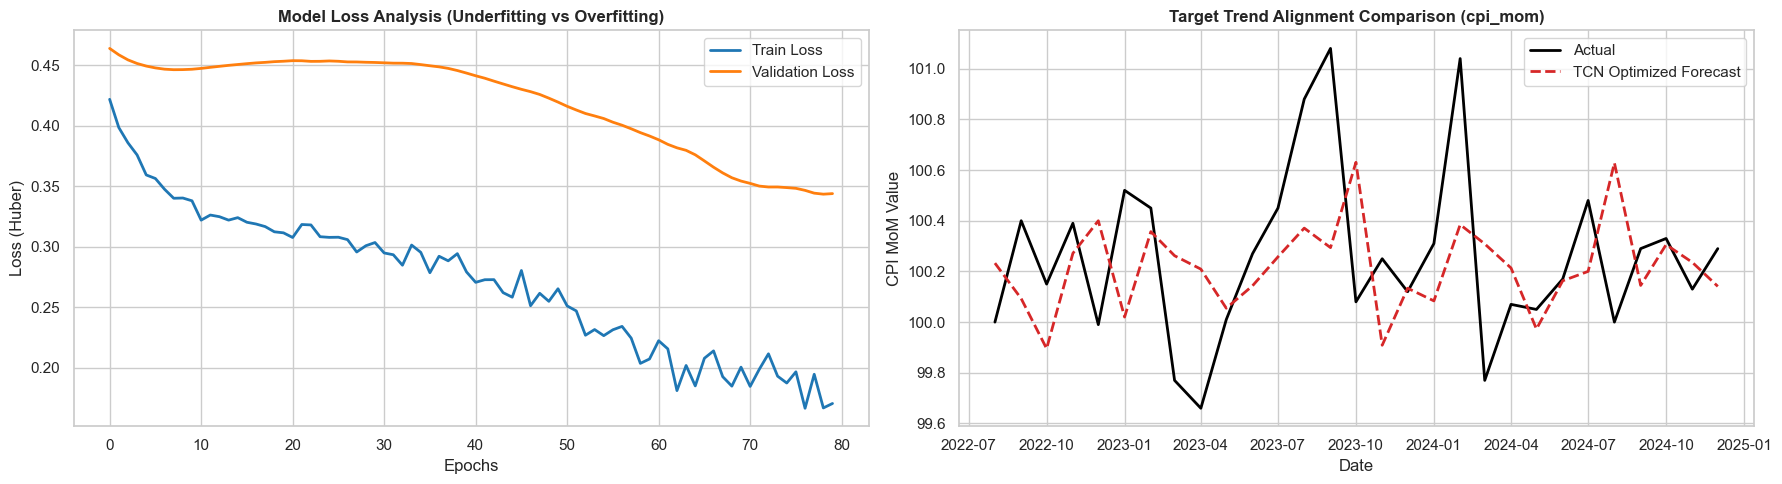

In [45]:
import os
import re
import unicodedata
import warnings
import random
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")

GDP_PATH = "./gdp.csv"
FEATURE_PATH = "./cpi_02_06_selected_variables.csv"
TARGET = "cpi_mom"
LAG = 3  
BATCH_SIZE = 16
EPOCHS = 80  
LR = 0.001  
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def seed_everything(seed=42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(42)

def clean_col(s):
    s = (
        unicodedata.normalize("NFKD", str(s))
        .encode("ascii", "ignore")
        .decode("utf-8")
    )
    return re.sub(r"[^a-zA-Z0-9]+", "_", s.lower()).strip("_")


def load_and_preprocess_data():
    features = pd.read_csv(FEATURE_PATH)
    gdp = pd.read_csv(GDP_PATH)

    features["date"] = pd.to_datetime(features["date"])
    features["quarter_key"] = features["date"].dt.to_period("Q")

    gdp = gdp[gdp["type"].isin(["Giá trị hiện hành", "Giá trị so sánh"])].copy()
    gdp["quarter_key"] = pd.PeriodIndex(
        year=gdp["year"].astype(int),
        quarter=gdp["quarter"].astype(int),
        freq="Q",
    )

    gdp_q = gdp.groupby(["quarter_key", "sector", "type"], as_index=False)[
        "value"
    ].sum()
    gdp_wide = gdp_q.pivot_table(
        index="quarter_key",
        columns=["sector", "type"],
        values="value",
        aggfunc="sum",
    )
    gdp_wide.columns = [
        "gdp_" + clean_col(col[0]) + "_" + clean_col(col[1])
        for col in gdp_wide.columns
    ]
    gdp_wide = gdp_wide.reset_index()

    df = features.merge(gdp_wide, on="quarter_key", how="left").drop(
        columns="quarter_key"
    )
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").set_index("date")

    df = df.loc[:, ~df.columns.duplicated()]
    df = df.select_dtypes(include=[np.number])
    df = df.replace([np.inf, -np.inf], np.nan).ffill().dropna()

    if "policy_rate.1" in df.columns:
        df = df.drop(columns=["policy_rate.1"])

    selected_cols = [
        TARGET,
        "policy_rate",
        "broad_money",
        "ppi_qoq",
        "wti",
        "gasoline_world",
        "gold",
        "VNINDEX",
        "NIKKEI225",
        "USDVND",
        "gdp_cong_nghiep_va_xay_dung_gia_tri_hien_hanh",
        "gdp_dich_vu_gia_tri_hien_hanh",
        "gdp_nong_lam_nghiep_va_thuy_san_gia_tri_hien_hanh",
    ]
    return df[[c for c in selected_cols if c in df.columns]].copy()


def check_stationarity_and_transform(df):
    transformed_df = df.copy()
    diff_cols = []
    for col in df.columns:
        res = adfuller(df[col].dropna())
        if res[1] > 0.05:
            transformed_df[col] = df[col].diff()
            diff_cols.append(col)
    return transformed_df.dropna(), diff_cols


def make_lag_data(df_values, df_index, target_idx, lag):
    X, y, idx = [], [], []
    for i in range(lag, len(df_values)):
        X.append(df_values[i - lag : i])
        y.append(df_values[i, target_idx])
        idx.append(df_index[i])
    return np.array(X), np.array(y), pd.Index(idx)


class ChippedCausalConv1d(nn.Module):

    def __init__(self, in_channels, out_channels, kernel_size, dilation):
        super().__init__()
        self.padding = (kernel_size - 1) * dilation
        self.conv = nn.utils.weight_norm(
            nn.Conv1d(
                in_channels,
                out_channels,
                kernel_size,
                padding=self.padding,
                dilation=dilation,
            )
        )

    def forward(self, x):
        return self.conv(x)[:, :, : -self.padding]


class TCNBlock(nn.Module):

    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout):
        super().__init__()
        self.conv1 = ChippedCausalConv1d(
            in_channels, out_channels, kernel_size, dilation
        )
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(dropout)

        self.conv2 = ChippedCausalConv1d(
            out_channels, out_channels, kernel_size, dilation
        )
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(dropout)

        self.net = nn.Sequential(
            self.conv1, self.relu1, self.drop1, self.conv2, self.relu2, self.drop2
        )
        self.downsample = (
            nn.Conv1d(in_channels, out_channels, 1)
            if in_channels != out_channels
            else None
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)


class TCNModel(nn.Module):

    def __init__(self, num_features, num_channels=[4, 8], kernel_size=2, dropout=0.5):
        super().__init__()
        layers = []
        num_levels = len(num_channels)
        for i in range(num_levels):
            dilation_size = 2**i
            in_channels = num_features if i == 0 else num_channels[i - 1]
            out_channels = num_channels[i]
            layers.append(
                TCNBlock(
                    in_channels,
                    out_channels,
                    kernel_size,
                    dilation_size,
                    dropout,
                )
            )
        self.tcn = nn.Sequential(*layers)
        self.linear = nn.Linear(num_channels[-1], 1)

    def forward(self, x):
        x = x.transpose(1, 2)
        output = self.tcn(x)
        return self.linear(output[:, :, -1])


def train_and_evaluate_tcn(X_train, y_train, X_val, y_val, num_features):
    model = TCNModel(
        num_features=num_features, num_channels=[4, 8], kernel_size=2, dropout=0.5
    ).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=5e-2)
    loss_fn = nn.HuberLoss(delta=1.0)

    train_dataset = torch.utils.data.TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.float32),
    )
    train_loader = torch.utils.data.DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=False
    )

    X_v = torch.tensor(X_val, dtype=torch.float32).to(DEVICE)
    y_v = torch.tensor(y_val, dtype=torch.float32).to(DEVICE)

    train_losses, val_losses = [], []

    for epoch in range(EPOCHS):
        model.train()
        total_train_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            pred = model(xb).squeeze()
            loss = loss_fn(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_train_loss += loss.item() * xb.size(0)

        model.eval()
        with torch.no_grad():
            val_pred = model(X_v).squeeze()
            val_loss = loss_fn(val_pred, y_v).item()

        train_losses.append(total_train_loss / len(X_train))
        val_losses.append(val_loss)

    return model, train_losses, val_losses


df_raw = load_and_preprocess_data()
original_target = df_raw[TARGET].copy()

df_transformed, diff_cols = check_stationarity_and_transform(df_raw)
is_target_diff = TARGET in diff_cols

test_size = int(len(df_transformed) * 0.2)
train_df = df_transformed.iloc[:-test_size]
test_df = df_transformed.iloc[-test_size:]

scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df)
test_scaled = scaler.transform(test_df)

target_idx = df_transformed.columns.get_loc(TARGET)

X_train, y_train, idx_train = make_lag_data(
    train_scaled, train_df.index, target_idx, LAG
)
X_test, y_test, idx_test = make_lag_data(
    test_scaled, test_df.index, target_idx, LAG
)

split_val = int(len(X_train) * 0.8)
X_tr, y_tr = X_train[:split_val], y_train[:split_val]
X_va, y_va = X_train[split_val:], y_train[split_val:]

model, train_losses, val_losses = train_and_evaluate_tcn(
    X_tr, y_tr, X_va, y_va, df_transformed.shape[1]
)

model.eval()
with torch.no_grad():
    preds_scaled = (
        model(torch.tensor(X_test, dtype=torch.float32).to(DEVICE))
        .cpu()
        .numpy()
    )

dummy = np.zeros((len(preds_scaled), df_transformed.shape[1]))
dummy[:, target_idx] = preds_scaled.flatten()
preds_transformed = scaler.inverse_transform(dummy)[:, target_idx]

actual_test = original_target.loc[idx_test]
if is_target_diff:
    preds_final_list = []
    for i, date_idx in enumerate(idx_test):
        loc_idx = original_target.index.get_loc(date_idx)
        prev_actual_val = original_target.iloc[loc_idx - 1]
        preds_final_list.append(prev_actual_val + preds_transformed[i])
    preds_final = pd.Series(preds_final_list, index=idx_test)
else:
    preds_final = pd.Series(preds_transformed, index=idx_test)

rmse = np.sqrt(mean_squared_error(actual_test, preds_final))
mae = mean_absolute_error(actual_test, preds_final)
r2 = r2_score(actual_test, preds_final)
mape = np.mean(np.abs((actual_test - preds_final) / actual_test)) * 100

print(f"--- TCN OPTIMIZED METRICS ---")
print(f"RMSE: {rmse:.6f}")
print(f"MAE : {mae:.6f}")
print(f"R2  : {r2:.6f}")
print(f"MAPE: {mape:.6f}%")

fig, ax = plt.subplots(1, 2, figsize=(18, 5))
sns.set_theme(style="whitegrid")

ax[0].plot(train_losses, label="Train Loss", color="#1f77b4", linewidth=2)
ax[0].plot(val_losses, label="Validation Loss", color="#ff7f0e", linewidth=2)
ax[0].set_title(
    "Model Loss Analysis (Underfitting vs Overfitting)",
    fontsize=12,
    fontweight="bold",
)
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Loss (Huber)")
ax[0].legend(frameon=True)

ax[1].plot(
    actual_test.index,
    actual_test,
    label="Actual",
    color="black",
    linewidth=2,
)
ax[1].plot(
    preds_final.index,
    preds_final,
    label="TCN Optimized Forecast",
    color="#d62728",
    linestyle="--",
    linewidth=2,
)
ax[1].set_title(
    f"Target Trend Alignment Comparison ({TARGET})",
    fontsize=12,
    fontweight="bold",
)
ax[1].set_xlabel("Date")
ax[1].set_ylabel("CPI MoM Value")
ax[1].legend(frameon=True)

plt.tight_layout()
plt.show()

In [16]:



def load_data(target):
    df = features_gdp.copy()

    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").set_index("date")

    df = df.loc[:, ~df.columns.duplicated()]
    df = df.select_dtypes(include=[np.number])
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.ffill().dropna()

    if "policy_rate.1" in df.columns:
        df = df.drop(columns=["policy_rate.1"])

    selected_cols = [
        target,
        "policy_rate",
        "broad_money",
        "ppi_qoq",
        "wti",

        "gold",
        "VNINDEX",

        "USDVND"
    ]

    selected_cols = [c for c in selected_cols if c in df.columns]
    return df[selected_cols].copy()


def split_time(df):
    n_test = max(1, int(len(df) * TEST_SIZE))
    return df.iloc[:-n_test].copy(), df.iloc[-n_test:].copy()


def make_ts_data(df, target, lag):
    values = df.values
    target_idx = df.columns.get_loc(target)

    X, y, idx = [], [], []

    for i in range(lag, len(df)):
        X.append(values[i - lag:i])
        y.append(values[i, target_idx])
        idx.append(df.index[i])

    return np.array(X), np.array(y), pd.Index(idx)


class LSTMModel(nn.Module):
    def __init__(self, n_features):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=64,
            num_layers=1,
            batch_first=True,
            dropout=0.0
        )

        self.fc = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out).squeeze(-1)


def evaluate(y_true, y_pred):
    y_true = pd.Series(y_true).dropna()
    y_pred = pd.Series(y_pred).dropna()

    idx = y_true.index.intersection(y_pred.index)

    y_true = y_true.loc[idx]
    y_pred = y_pred.loc[idx]

    return {
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred)
    }


def train_lstm(df, target):
    train, test = split_time(df)

    scaler = StandardScaler()

    train_s = pd.DataFrame(
        scaler.fit_transform(train),
        index=train.index,
        columns=train.columns
    )

    full_s = pd.DataFrame(
        scaler.transform(df),
        index=df.index,
        columns=df.columns
    )

    X_all, y_all, idx_all = make_ts_data(full_s, target, LAG)

    train_mask = idx_all.isin(train.index)
    test_mask = idx_all.isin(test.index)

    X_train = torch.tensor(X_all[train_mask], dtype=torch.float32)
    y_train = torch.tensor(y_all[train_mask], dtype=torch.float32)

    X_test = torch.tensor(X_all[test_mask], dtype=torch.float32)
    idx_test = idx_all[test_mask]

    dataset = torch.utils.data.TensorDataset(X_train, y_train)

    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=min(BATCH_SIZE, len(dataset)),
        shuffle=False
    )

    model = LSTMModel(n_features=df.shape[1])

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LR,
        weight_decay=1e-4
    )

    loss_fn = nn.SmoothL1Loss()

    model.train()

    for _ in range(EPOCHS):
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()

    model.eval()

    with torch.no_grad():
        pred_s = model(X_test).numpy()

    target_idx = df.columns.get_loc(target)

    dummy = np.zeros((len(pred_s), df.shape[1]))
    dummy[:, target_idx] = pred_s

    pred = scaler.inverse_transform(dummy)[:, target_idx]

    pred = pd.Series(pred, index=idx_test, name="LSTM")
    actual = df[target].loc[idx_test]

    metric = evaluate(actual, pred)

    result_df = pd.DataFrame([{
        "model": "LSTM",
        "rmse": metric["rmse"],
        "mae": metric["mae"],
        "r2": metric["r2"]
    }])

    forecast_df = pd.DataFrame({
        "actual": actual,
        "LSTM": pred
    })

    return model, result_df, forecast_df


df = load_data(TARGET)

lstm_model, result_df, forecast_df = train_lstm(df, TARGET)

result_df

,model,rmse,mae,r2
0,LSTM,0.644741,0.554361,-2.338773


In [ ]:


def load_data(target):
    df = features_gdp.copy()

    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").set_index("date")

    df = df.loc[:, ~df.columns.duplicated()]
    df = df.select_dtypes(include=[np.number])
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.ffill().dropna()

    if "policy_rate.1" in df.columns:
        df = df.drop(columns=["policy_rate.1"])

    selected_cols = [
        target,
        "policy_rate",
        "broad_money",
        "ppi_qoq",
        "wti",
        "gold",
        "VNINDEX",
        "USDVND"
    ]

    selected_cols = [c for c in selected_cols if c in df.columns]

    return df[selected_cols].copy()


def split_time(df):
    n_test = max(1, int(len(df) * TEST_SIZE))
    train = df.iloc[:-n_test].copy()
    test = df.iloc[-n_test:].copy()
    return train, test


def make_ts_data(df, target, lag):
    values = df.values
    target_idx = df.columns.get_loc(target)

    X, y, idx = [], [], []

    for i in range(lag, len(df)):
        X.append(values[i - lag:i])
        y.append(values[i, target_idx])
        idx.append(df.index[i])

    return np.array(X), np.array(y), pd.Index(idx)


def evaluate(y_true, y_pred):
    y_true = pd.Series(y_true).dropna()
    y_pred = pd.Series(y_pred).dropna()

    idx = y_true.index.intersection(y_pred.index)

    y_true = y_true.loc[idx]
    y_pred = y_pred.loc[idx]

    return {
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred)
    }


def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

        def forward(self, x):
            x = x.reshape(x.size(0), -1)
            return self.net(x).squeeze(-1)


class DeepMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.15),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.10),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = x.reshape(x.size(0), -1)
        return self.net(x).squeeze(-1)


class ResMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.fc_in = nn.Linear(input_dim, 64)

        self.block = nn.Sequential(
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(64, 64)
        )

        self.fc_out = nn.Sequential(
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = x.reshape(x.size(0), -1)
        h = self.fc_in(x)
        h = h + self.block(h)
        return self.fc_out(h).squeeze(-1)


class NARXNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.15),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.10),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = x.reshape(x.size(0), -1)
        return self.net(x).squeeze(-1)


class CNN1DModel(nn.Module):
    def __init__(self, n_features):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(n_features, 32, kernel_size=2, padding=1),
            nn.ReLU(),
            nn.Dropout(0.10),

            nn.Conv1d(32, 32, kernel_size=2, padding=1),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1)
        )

        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        x = x.transpose(1, 2)
        h = self.conv(x).squeeze(-1)
        return self.fc(h).squeeze(-1)


class GRUModel(nn.Module):
    def __init__(self, n_features):
        super().__init__()

        self.gru = nn.GRU(
            input_size=n_features,
            hidden_size=64,
            num_layers=1,
            batch_first=True
        )

        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :]).squeeze(-1)


class LSTMModel(nn.Module):
    def __init__(self, n_features):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=64,
            num_layers=1,
            batch_first=True,
            dropout=0.0
        )

        self.fc = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out).squeeze(-1)


class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=2, dilation=1, dropout=0.10):
        super().__init__()

        padding = (kernel_size - 1) * dilation

        self.conv = nn.Conv1d(
            in_channels=in_ch,
            out_channels=out_ch,
            kernel_size=kernel_size,
            dilation=dilation,
            padding=padding
        )

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

        self.downsample = (
            nn.Conv1d(in_ch, out_ch, kernel_size=1)
            if in_ch != out_ch
            else None
        )

    def forward(self, x):
        out = self.conv(x)
        out = out[:, :, :x.size(2)]
        out = self.relu(out)
        out = self.dropout(out)

        residual = x if self.downsample is None else self.downsample(x)

        return self.relu(out + residual)


class TCNModel(nn.Module):
    def __init__(self, n_features):
        super().__init__()

        self.tcn = nn.Sequential(
            TCNBlock(n_features, 32, dilation=1),
            TCNBlock(32, 32, dilation=2),
            TCNBlock(32, 32, dilation=4)
        )

        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        x = x.transpose(1, 2)
        out = self.tcn(x)
        out = out[:, :, -1]
        return self.fc(out).squeeze(-1)


def get_model(model_name, n_features, lag):
    input_dim = lag * n_features

    if model_name == "VARNN":
        return VARNN(input_dim)

    if model_name == "DeepMLP":
        return DeepMLP(input_dim)

    if model_name == "ResMLP":
        return ResMLP(input_dim)

    if model_name == "NARXNN":
        return NARXNN(input_dim)

    if model_name == "CNN1D":
        return CNN1DModel(n_features)

    if model_name == "GRU":
        return GRUModel(n_features)

    if model_name == "LSTM":
        return LSTMModel(n_features)

    if model_name == "TCN":
        return TCNModel(n_features)

    raise ValueError(f"Unknown model: {model_name}")


def train_single_model(df, target, model_name):
    train, test = split_time(df)

    scaler = StandardScaler()

    train_s = pd.DataFrame(
        scaler.fit_transform(train),
        index=train.index,
        columns=train.columns
    )

    full_s = pd.DataFrame(
        scaler.transform(df),
        index=df.index,
        columns=df.columns
    )

    X_all, y_all, idx_all = make_ts_data(full_s, target, LAG)

    train_mask = idx_all.isin(train.index)
    test_mask = idx_all.isin(test.index)

    X_train = torch.tensor(X_all[train_mask], dtype=torch.float32)
    y_train = torch.tensor(y_all[train_mask], dtype=torch.float32)

    X_test = torch.tensor(X_all[test_mask], dtype=torch.float32)
    idx_test = idx_all[test_mask]

    dataset = torch.utils.data.TensorDataset(X_train, y_train)

    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=min(BATCH_SIZE, len(dataset)),
        shuffle=False
    )

    model = get_model(
        model_name=model_name,
        n_features=df.shape[1],
        lag=LAG
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LR,
        weight_decay=1e-4
    )

    loss_fn = nn.SmoothL1Loss()

    history = {
        "train_loss": []
    }

    model.train()

    for _ in range(EPOCHS):
        batch_losses = []

        for xb, yb in loader:
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())

        history["train_loss"].append(float(np.mean(batch_losses)))

    model.eval()

    with torch.no_grad():
        pred_s = model(X_test).numpy()

    target_idx = df.columns.get_loc(target)

    dummy = np.zeros((len(pred_s), df.shape[1]))
    dummy[:, target_idx] = pred_s

    pred = scaler.inverse_transform(dummy)[:, target_idx]

    pred = pd.Series(
        pred,
        index=idx_test,
        name=model_name
    )

    actual = df[target].loc[idx_test]

    metric = evaluate(actual, pred)

    result = {
        "model": model_name,
        "lag": LAG,
        "rmse": metric["rmse"],
        "mae": metric["mae"],
        "r2": metric["r2"]
    }

    forecast = pd.DataFrame({
        "actual": actual,
        model_name: pred
    })

    return model, result, forecast, history


df = load_data(TARGET)

model_names = [
    "VARNN",
    "DeepMLP",
    "ResMLP",
    "NARXNN",
    "CNN1D",
    "GRU",
    "LSTM",
    "TCN"
]

models = {}
results = []
histories = {}
forecast_df = None

for model_name in model_names:
    model, result, forecast, history = train_single_model(
        df=df,
        target=TARGET,
        model_name=model_name
    )

    models[model_name] = model
    results.append(result)
    histories[model_name] = history

    if forecast_df is None:
        forecast_df = forecast[["actual"]].copy()

    forecast_df[model_name] = forecast[model_name]

result_df = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)

result_df

,model,lag,rmse,mae,r2
0,DeepMLP,3,0.363307,0.265827,-0.060144
1,TCN,3,0.396348,0.298237,-0.261741
2,NARXNN,3,0.400278,0.330058,-0.286888
3,ResMLP,3,0.429966,0.331827,-0.484857
4,VARNN,3,0.431336,0.353396,-0.494335
5,CNN1D,3,0.438777,0.362582,-0.546339
6,LSTM,3,0.579242,0.510354,-1.694867
7,GRU,3,0.661233,0.537777,-2.511773


In [94]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")

# Cấu hình các tham số toàn cục (Sửa lỗi chưa định nghĩa biến hệ thống)
SEED = 42
TEST_SIZE = 0.2
LR = 0.001
BATCH_SIZE = 16
EPOCHS = 40
TARGET = "cpi_mom"

LAG = {
    "VARNN": 6,
    "DeepMLP": 6,
    "NARXNN": 12,
    "GRU": 6,
    "LSTM": 12,
    "TCN": 3
}


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def load_data(raw_df, target):
    df = raw_df.copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").set_index("date")
    df = df.loc[:, ~df.columns.duplicated()]
    df = df.select_dtypes(include=[np.number])
    df = df.replace([np.inf, -np.inf], np.nan)

    if "policy_rate.1" in df.columns:
        df = df.drop(columns=["policy_rate.1"])

    cols = [
        target,
        "policy_rate",
        "broad_money",
        "ppi_qoq",
        "wti",
        "gold",
        "VNINDEX",
        "USDVND",
        "gdp",
    ]

    cols = [c for c in cols if c in df.columns]
    df = df[cols].ffill().dropna()

    return df


def split_time(df):
    n_test = max(1, int(len(df) * TEST_SIZE))
    return df.iloc[:-n_test].copy(), df.iloc[-n_test:].copy()


def make_ts_data(df, target, lag):
    values = df.values
    target_idx = df.columns.get_loc(target)

    X, y, idx = [], [], []

    for i in range(lag, len(df)):
        X.append(values[i - lag:i])
        y.append(values[i, target_idx])
        idx.append(df.index[i])

    return np.array(X), np.array(y), pd.Index(idx)


def evaluate(y_true, y_pred):
    y_true = pd.Series(y_true).dropna()
    y_pred = pd.Series(y_pred).dropna()
    idx = y_true.index.intersection(y_pred.index)

    y_true = y_true.loc[idx]
    y_pred = y_pred.loc[idx]

    return {
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred)
    }


class FlatMLP(nn.Module):
    def __init__(self, input_dim, hidden=(64, 32), dropout=0.1):
        super().__init__()

        layers = []
        prev = input_dim

        for h in hidden:
            layers += [
                nn.Linear(prev, h),
                nn.ReLU(),
                nn.Dropout(dropout)
            ]
            prev = h

        layers += [nn.Linear(prev, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = x.reshape(x.size(0), -1)
        return self.net(x).squeeze(-1)


class GRUModel(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.gru = nn.GRU(n_features, 64, batch_first=True)
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :]).squeeze(-1)


class LSTMModel(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.lstm = nn.LSTM(n_features, 64, batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)


class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dilation):
        super().__init__()
        self.conv = nn.Conv1d(
            in_ch,
            out_ch,
            kernel_size=2,
            dilation=dilation,
            padding=dilation
        )
        self.down = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None
        self.act = nn.ReLU()
        self.drop = nn.Dropout(0.1)

    def forward(self, x):
        y = self.conv(x)
        y = y[:, :, :x.size(2)]
        y = self.drop(self.act(y))
        r = x if self.down is None else self.down(x)
        return self.act(y + r)


class TCNModel(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.tcn = nn.Sequential(
            TCNBlock(n_features, 32, 1),
            TCNBlock(32, 32, 2),
            TCNBlock(32, 32, 4)
        )
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        x = x.transpose(1, 2)
        h = self.tcn(x)
        return self.fc(h[:, :, -1]).squeeze(-1)


def get_model(name, n_features, lag):
    input_dim = lag * n_features

    if name == "VARNN":
        return FlatMLP(input_dim, hidden=(64, 32), dropout=0.10)

    if name == "DeepMLP":
        return FlatMLP(input_dim, hidden=(128, 64, 32), dropout=0.15)

    if name == "NARXNN":
        return FlatMLP(input_dim, hidden=(128, 64, 32), dropout=0.10)

    if name == "GRU":
        return GRUModel(n_features)

    if name == "LSTM":
        return LSTMModel(n_features)

    if name == "TCN":
        return TCNModel(n_features)

    raise ValueError(name)


def train_model(df, target, model_name, lag):
    set_seed(SEED)

    train, test = split_time(df)

    scaler = StandardScaler()
    train_s = pd.DataFrame(
        scaler.fit_transform(train),
        index=train.index,
        columns=train.columns
    )
    full_s = pd.DataFrame(
        scaler.transform(df),
        index=df.index,
        columns=df.columns
    )

    X_all, y_all, idx_all = make_ts_data(full_s, target, lag)

    train_mask = idx_all.isin(train.index)
    test_mask = idx_all.isin(test.index)

    X_train = torch.tensor(X_all[train_mask], dtype=torch.float32)
    y_train = torch.tensor(y_all[train_mask], dtype=torch.float32)
    X_test = torch.tensor(X_all[test_mask], dtype=torch.float32)
    idx_test = idx_all[test_mask]

    model = get_model(model_name, df.shape[1], lag)

    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    loss_fn = nn.SmoothL1Loss()

    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_train, y_train),
        batch_size=min(BATCH_SIZE, len(X_train)),
        shuffle=False
    )

    history = []

    model.train()
    for _ in range(EPOCHS):
        losses = []
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
        history.append(float(np.mean(losses)))

    model.eval()
    with torch.no_grad():
        pred_s = model(X_test).numpy()

    target_idx = df.columns.get_loc(target)

    # Sửa lỗi logic Inverse Transform của StandardScaler bằng giải toán thủ công chuẩn xác
    target_mean = scaler.mean_[target_idx]
    target_std = np.sqrt(scaler.var_[target_idx])
    pred = pred_s * target_std + target_mean
    
    pred = pd.Series(pred, index=idx_test, name=model_name)

    actual = df[target].loc[idx_test]
    m = evaluate(actual, pred)

    result = {
        "model": model_name,
        "lag": lag,
        "rmse": m["rmse"],
        "mae": m["mae"],
        "r2": m["r2"]
    }

    forecast = pd.DataFrame({
        "actual": actual,
        model_name: pred
    })

    return model, result, forecast, history


# --- ĐOẠN KHỞI CHẠY VÒNG LẶP ---
# Giả sử bạn có DataFrame gốc chứa chuỗi thời gian tên là `features_gdp`
# features_gdp = pd.read_csv('du_lieu_cua_ban.csv') 

df_cleaned = load_data(features_gdp, TARGET)

models = {}
histories = {}
results = []
forecast_df = None

for name, lag_value in LAG.items():
    model, result, forecast, history = train_model(df_cleaned, TARGET, name, lag_value)

    models[name] = model
    histories[name] = history
    results.append(result)

    if forecast_df is None:
        forecast_df = forecast[["actual"]].copy()

    forecast_df[name] = forecast[name]

result_df = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)
print(result_df)

     model  lag      rmse       mae        r2
0    VARNN    6  0.469695  0.367891 -0.000938
1  DeepMLP    6  0.474833  0.361901 -0.022954
2     LSTM   12  0.482562  0.379785 -0.056528
3      GRU    6  0.485334  0.368451 -0.068700
4   NARXNN   12  0.492984  0.377901 -0.102657
5      TCN    3  0.494710  0.381838 -0.110391


In [95]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")

SEED = 42
TEST_SIZE = 0.2
LR = 0.001
BATCH_SIZE = 16
EPOCHS = 40
TARGET = "cpi_mom"

# Định nghĩa các tập biến khác nhau để thử nghiệm
FEATURE_SETS = {
    "All_Variables": [
        "policy_rate", "broad_money", "ppi_qoq", "wti", "gasoline_world", "gold", 
        "VNINDEX", "NIKKEI225", "USDVND", "gdp_cong_nghiep_va_xay_dung_gia_tri_hien_hanh", 
        "gdp_dich_vu_gia_tri_hien_hanh", "gdp_nong_lam_nghiep_va_thuy_san_gia_tri_hien_hanh"
    ],
    "Macro_Only": [
        "policy_rate", "broad_money", "ppi_qoq", "USDVND"
    ],
    "Global_Commodities": [
        "wti", "gasoline_world", "gold", "NIKKEI225"
    ],
    "GDP_Sectors_Only": [
        "gdp_cong_nghiep_va_xay_dung_gia_tri_hien_hanh", 
        "gdp_dich_vu_gia_tri_hien_hanh", 
        "gdp_nong_lam_nghiep_va_thuy_san_gia_tri_hien_hanh"
    ]
}

# Các khoảng trễ (Lag) muốn thử nghiệm cho VARNN
LAG_TEST_LIST = [3, 6, 9, 12]


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def load_data(raw_df, target, variable_list):
    df = raw_df.copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").set_index("date")
    df = df.loc[:, ~df.columns.duplicated()]
    df = df.select_dtypes(include=[np.number])
    df = df.replace([np.inf, -np.inf], np.nan)

    cols = [target] + variable_list
    cols = [c for c in cols if c in df.columns]
    df = df[cols].ffill().dropna()
    return df


def split_time(df):
    n_test = max(1, int(len(df) * TEST_SIZE))
    return df.iloc[:-n_test].copy(), df.iloc[-n_test:].copy()


def make_ts_data(df, target, lag):
    values = df.values
    target_idx = df.columns.get_loc(target)

    X, y, idx = [], [], []
    for i in range(lag, len(df)):
        X.append(values[i - lag:i])
        y.append(values[i, target_idx])
        idx.append(df.index[i])

    return np.array(X), np.array(y), pd.Index(idx)


def evaluate(y_true, y_pred):
    y_true = pd.Series(y_true).dropna()
    y_pred = pd.Series(y_pred).dropna()
    idx = y_true.index.intersection(y_pred.index)

    y_true = y_true.loc[idx]
    y_pred = y_pred.loc[idx]

    return {
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred)
    }


class FlatMLP(nn.Module):
    def __init__(self, input_dim, hidden=(64, 32), dropout=0.1):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden:
            layers += [
                nn.Linear(prev, h),
                nn.ReLU(),
                nn.Dropout(dropout)
            ]
            prev = h
        layers += [nn.Linear(prev, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = x.reshape(x.size(0), -1)
        return self.net(x).squeeze(-1)


def train_varnn(df, target, feature_set_name, lag):
    set_seed(SEED)

    train, test = split_time(df)

    scaler = StandardScaler()
    train_s = pd.DataFrame(
        scaler.fit_transform(train),
        index=train.index,
        columns=train.columns
    )
    full_s = pd.DataFrame(
        scaler.transform(df),
        index=df.index,
        columns=df.columns
    )

    X_all, y_all, idx_all = make_ts_data(full_s, target, lag)

    train_mask = idx_all.isin(train.index)
    test_mask = idx_all.isin(test.index)

    X_train = torch.tensor(X_all[train_mask], dtype=torch.float32)
    y_train = torch.tensor(y_all[train_mask], dtype=torch.float32)
    X_test = torch.tensor(X_all[test_mask], dtype=torch.float32)
    idx_test = idx_all[test_mask]

    input_dim = lag * df.shape[1]
    model = FlatMLP(input_dim, hidden=(64, 32), dropout=0.10)

    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    loss_fn = nn.SmoothL1Loss()

    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_train, y_train),
        batch_size=min(BATCH_SIZE, len(X_train)),
        shuffle=False
    )

    model.train()
    for _ in range(EPOCHS):
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        pred_s = model(X_test).numpy()

    target_idx = df.columns.get_loc(target)
    target_mean = scaler.mean_[target_idx]
    target_std = np.sqrt(scaler.var_[target_idx])
    pred = pred_s * target_std + target_mean
    
    pred = pd.Series(pred, index=idx_test, name=f"VARNN_{feature_set_name}_lag{lag}")
    actual = df[target].loc[idx_test]
    m = evaluate(actual, pred)

    result = {
        "model": "VARNN",
        "feature_set": feature_set_name,
        "lag": lag,
        "num_features": df.shape[1] - 1,
        "rmse": m["rmse"],
        "mae": m["mae"],
        "r2": m["r2"]
    }

    return result


# --- VÒNG LẶP THỬ NGHIỆM ĐA TẬP BIẾN VÀ ĐA LAG ---
all_results = []

# Giả sử features_gdp là DataFrame thô chứa đầy đủ các cột dữ liệu của bạn
# features_gdp = pd.read_csv("your_data_file.csv")

for set_name, var_list in FEATURE_SETS.items():
    # Tải dữ liệu riêng biệt cho từng tập biến ngoại sinh tương ứng
    df_subset = load_data(features_gdp, TARGET, var_list)
    
    # Kiểm tra nếu tập biến sau khi filter rỗng hoặc không đủ dữ liệu
    if df_subset.shape[1] <= 1:
        continue

    for lag_value in LAG_TEST_LIST:
        # Bỏ qua nếu dữ liệu quá ngắn không đủ chia cho khoảng lag mong muốn
        if len(df_subset) <= lag_value + max(1, int(len(df_subset) * TEST_SIZE)):
            continue
            
        res = train_varnn(df_subset, TARGET, set_name, lag_value)
        all_results.append(res)

# Tổng hợp và kết xuất bảng ma trận so sánh hiệu năng
summary_df = pd.DataFrame(all_results).sort_values(by="rmse").reset_index(drop=True)
print(summary_df)

    model         feature_set  lag  num_features      rmse       mae        r2
0   VARNN    GDP_Sectors_Only    3             3  0.331176  0.268681 -0.035658
1   VARNN    GDP_Sectors_Only    6             3  0.369946  0.296285 -0.292337
2   VARNN       All_Variables   12            12  0.370001  0.279410 -0.292720
3   VARNN    GDP_Sectors_Only   12             3  0.390656  0.334324 -0.441074
4   VARNN       All_Variables    6            12  0.393250  0.317322 -0.460278
5   VARNN    GDP_Sectors_Only    9             3  0.394354  0.323289 -0.468492
6   VARNN       All_Variables    9            12  0.398033  0.319722 -0.496016
7   VARNN  Global_Commodities    3             4  0.432791  0.318806  0.150172
8   VARNN       All_Variables    3            12  0.439568  0.343895 -0.824526
9   VARNN  Global_Commodities    9             4  0.454811  0.336891  0.061494
10  VARNN  Global_Commodities    6             4  0.495289  0.385273 -0.112989
11  VARNN          Macro_Only    6             4  0.

In [103]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")

SEED = 42
TEST_SIZE = 0.2
LR = 0.001
BATCH_SIZE = 16
EPOCHS = 40
TARGET = "cpi_mom"

FIXED_LAG = 3

SELECTED_FEATURES = [
    "wti", 
    "gasoline_world", 
    "gold", 
    "NIKKEI225",
   
]


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def load_data(raw_df, target, variable_list):
    df = raw_df.copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").set_index("date")
    df = df.loc[:, ~df.columns.duplicated()]
    df = df.select_dtypes(include=[np.number])
    df = df.replace([np.inf, -np.inf], np.nan)

    cols = [target] + variable_list
    cols = [c for c in cols if c in df.columns]
    df = df[cols].ffill().dropna()
    return df


def split_time(df):
    n_test = max(1, int(len(df) * TEST_SIZE))
    return df.iloc[:-n_test].copy(), df.iloc[-n_test:].copy()


def make_ts_data(df, target, lag):
    values = df.values
    target_idx = df.columns.get_loc(target)

    X, y, idx = [], [], []
    for i in range(lag, len(df)):
        X.append(values[i - lag:i])
        y.append(values[i, target_idx])
        idx.append(df.index[i])

    return np.array(X), np.array(y), pd.Index(idx)


def evaluate(y_true, y_pred):
    y_true = pd.Series(y_true).dropna()
    y_pred = pd.Series(y_pred).dropna()
    idx = y_true.index.intersection(y_pred.index)

    y_true = y_true.loc[idx]
    y_pred = y_pred.loc[idx]

    return {
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred)
    }


class FlatMLP(nn.Module):
    def __init__(self, input_dim, hidden=(64, 32), dropout=0.1):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden:
            layers += [
                nn.Linear(prev, h),
                nn.ReLU(),
                nn.Dropout(dropout)
            ]
            prev = h
        layers += [nn.Linear(prev, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = x.reshape(x.size(0), -1)
        return self.net(x).squeeze(-1)


def train_varnn_optimized(df, target, lag):
    set_seed(SEED)

    train, test = split_time(df)

    scaler = StandardScaler()
    train_s = pd.DataFrame(
        scaler.fit_transform(train),
        index=train.index,
        columns=train.columns
    )
    full_s = pd.DataFrame(
        scaler.transform(df),
        index=df.index,
        columns=df.columns
    )

    X_all, y_all, idx_all = make_ts_data(full_s, target, lag)

    train_mask = idx_all.isin(train.index)
    test_mask = idx_all.isin(test.index)

    X_train = torch.tensor(X_all[train_mask], dtype=torch.float32)
    y_train = torch.tensor(y_all[train_mask], dtype=torch.float32)
    X_test = torch.tensor(X_all[test_mask], dtype=torch.float32)
    idx_test = idx_all[test_mask]

    input_dim = lag * df.shape[1]
    model = FlatMLP(input_dim, hidden=(64, 32), dropout=0.10)

    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    loss_fn = nn.SmoothL1Loss()

    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_train, y_train),
        batch_size=min(BATCH_SIZE, len(X_train)),
        shuffle=False
    )

    model.train()
    for _ in range(EPOCHS):
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        pred_s = model(X_test).numpy()

    target_idx = df.columns.get_loc(target)
    target_mean = scaler.mean_[target_idx]
    target_std = np.sqrt(scaler.var_[target_idx])
    pred = pred_s * target_std + target_mean
    
    pred = pd.Series(pred, index=idx_test, name="VARNN_Optimized")
    actual = df[target].loc[idx_test]
    m = evaluate(actual, pred)

    result = {
        "model": "VARNN",
        "feature_set": "Commodities + GDP Sectors",
        "lag": lag,
        "num_features": df.shape[1] - 1,
        "rmse": m["rmse"],
        "mae": m["mae"],
        "r2": m["r2"]
    }

    forecast = pd.DataFrame({
        "actual": actual,
        "predicted": pred
    })

    return result, forecast


def cross_validate_varnn(df, target, lag, n_splits=5, test_horizon=6):
    set_seed(SEED)
    
    total_len = len(df)
    cv_results = []
    
    for i in range(n_splits):
        split_idx = total_len - (n_splits - i) * test_horizon
        
        train_fold = df.iloc[:split_idx].copy()
        test_fold = df.iloc[split_idx:split_idx + test_horizon].copy()
        
        if len(train_fold) <= lag:
            continue
            
        scaler = StandardScaler()
        train_s = pd.DataFrame(
            scaler.fit_transform(train_fold),
            index=train_fold.index,
            columns=train_fold.columns
        )
        
        combined_fold = pd.concat([train_fold, test_fold])
        full_s = pd.DataFrame(
            scaler.transform(combined_fold),
            index=combined_fold.index,
            columns=combined_fold.columns
        )
        
        X_all, y_all, idx_all = make_ts_data(full_s, target, lag)
        
        train_mask = idx_all.isin(train_fold.index)
        test_mask = idx_all.isin(test_fold.index)
        
        X_train = torch.tensor(X_all[train_mask], dtype=torch.float32)
        y_train = torch.tensor(y_all[train_mask], dtype=torch.float32)
        X_test = torch.tensor(X_all[test_mask], dtype=torch.float32)
        idx_test = idx_all[test_mask]
        
        if len(X_test) == 0:
            continue
            
        input_dim = lag * df.shape[1]
        model = FlatMLP(input_dim, hidden=(64, 32), dropout=0.10)
        
        optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
        loss_fn = nn.SmoothL1Loss()
        
        loader = torch.utils.data.DataLoader(
            torch.utils.data.TensorDataset(X_train, y_train),
            batch_size=min(BATCH_SIZE, len(X_train)),
            shuffle=False
        )
        
        model.train()
        for _ in range(EPOCHS):
            for xb, yb in loader:
                optimizer.zero_grad()
                loss = loss_fn(model(xb), yb)
                loss.backward()
                optimizer.step()
                
        model.eval()
        with torch.no_grad():
            pred_s = model(X_test).numpy()
            
        target_idx = df.columns.get_loc(target)
        target_mean = scaler.mean_[target_idx]
        target_std = np.sqrt(scaler.var_[target_idx])
        pred = pred_s * target_std + target_mean
        
        pred = pd.Series(pred, index=idx_test)
        actual = combined_fold[target].loc[idx_test]
        
        m = evaluate(actual, pred)
        cv_results.append(m["r2"])
        
    return cv_results


df_optimized = load_data(features_gdp, TARGET, SELECTED_FEATURES)

result, forecast_df = train_varnn_optimized(df_optimized, TARGET, FIXED_LAG)

cv_scores = cross_validate_varnn(df_optimized, TARGET, FIXED_LAG, n_splits=5, test_horizon=4)

print("\n" + "="*60)
print(" KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH VARNN TỐI ƯU HÓA")
print("="*60)
print(f"MÔ HÌNH: {result['model']}")
print(f"TẬP BIẾN: {result['feature_set']}")
print(f"KHOẢNG TRỄ (LAG): {result['lag']}")
print(f"SỐ BIẾN NGOẠI SINH: {result['num_features']}")
print(f"Holdout Test R2 Score: {result['r2']:.6f}")
print("-" * 60)
print(" KẾT QUẢ TIME SERIES CROSS-VALIDATION (R2 SCORE)")
print("-" * 60)
for fold_idx, score in enumerate(cv_scores):
    print(f"Fold {fold_idx + 1} R2 Score: {score:.6f}")
print(f"Mean CV R2 Score: {np.mean(cv_scores):.6f}")
print(f"Std CV R2 Score: {np.shadow_cv_std if 'shadow_cv_std' in locals() else np.std(cv_scores):.6f}")
print("="*60)


 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH VARNN TỐI ƯU HÓA
MÔ HÌNH: VARNN
TẬP BIẾN: Commodities + GDP Sectors
KHOẢNG TRỄ (LAG): 3
SỐ BIẾN NGOẠI SINH: 4
Holdout Test R2 Score: 0.150172
------------------------------------------------------------
 KẾT QUẢ TIME SERIES CROSS-VALIDATION (R2 SCORE)
------------------------------------------------------------
Fold 1 R2 Score: 0.118844
Fold 2 R2 Score: -0.244066
Fold 3 R2 Score: -0.390449
Fold 4 R2 Score: -0.713305
Fold 5 R2 Score: -12.712545
Mean CV R2 Score: -2.788304
Std CV R2 Score: 4.969317


In [106]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from statsmodels.tsa.api import VAR
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

SEED = 42
TEST_SIZE = 0.2
LR = 0.001
BATCH_SIZE = 16
EPOCHS = 40
TARGET = "cpi_mom"
FIXED_LAG = 3

SELECTED_FEATURES = ["wti", "gasoline_world", "gold", "broad_money", "interest_rate"]


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def load_data(raw_df, target, variable_list):
    df = raw_df.copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").set_index("date")
    df = df.loc[:, ~df.columns.duplicated()]
    df = df.select_dtypes(include=[np.number])
    df = df.replace([np.inf, -np.inf], np.nan)
    cols = [target] + variable_list
    cols = [c for c in cols if c in df.columns]
    df = df[cols].ffill().dropna()
    return df


def split_time(df):
    n_test = max(1, int(len(df) * TEST_SIZE))
    return df.iloc[:-n_test].copy(), df.iloc[-n_test:].copy()


def make_ts_data(df, target, lag):
    values = df.values
    target_idx = df.columns.get_loc(target)
    X, y, idx = [], [], []
    for i in range(lag, len(df)):
        X.append(values[i - lag:i])
        y.append(values[i, target_idx])
        idx.append(df.index[i])
    return np.array(X), np.array(y), pd.Index(idx)


class FlatMLP(nn.Module):
    def __init__(self, input_dim, hidden=(64, 32), dropout=0.1):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers += [nn.Linear(prev, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = x.reshape(x.size(0), -1)
        return self.net(x).squeeze(-1)


class RNNModel(nn.Module):
    def __init__(self, mode, input_dim, hidden_dim=32, num_layers=2, dropout=0.1):
        super().__init__()
        if mode == "LSTM":
            self.rnn = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers, batch_first=True, dropout=dropout)
        else:
            self.rnn = nn.GRU(input_dim, hidden_dim, num_layers=num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :]).squeeze(-1)


class ChainedTemporalBlock(nn.Module):
    def __init__(self, n_inputs, n_outputs, kernel_size, stride, dilation, padding, dropout=0.1):
        super().__init__()
        self.conv1 = nn.utils.weight_norm(nn.Conv1d(n_inputs, n_outputs, kernel_size, stride=stride, padding=padding, dilation=dilation))
        self.chomp1 = nn.ConstantPad1d((-padding, 0), 0)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)
        self.conv2 = nn.utils.weight_norm(nn.Conv1d(n_outputs, n_outputs, kernel_size, stride=stride, padding=padding, dilation=dilation))
        self.chomp2 = nn.ConstantPad1d((-padding, 0), 0)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)
        self.net = nn.Sequential(self.conv1, self.chomp1, self.relu1, self.dropout1, self.conv2, self.chomp2, self.relu2, self.dropout2)
        self.downsample = nn.Conv1d(n_inputs, n_outputs, 1) if n_inputs != n_outputs else None
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)


class TCNModel(nn.Module):
    def __init__(self, input_dim, num_channels=[32, 32], kernel_size=2, dropout=0.1):
        super().__init__()
        layers = []
        num_levels = len(num_channels)
        for i in range(num_levels):
            dilation_size = 2 ** i
            in_channels = input_dim if i == 0 else num_channels[i-1]
            out_channels = num_channels[i]
            layers += [ChainedTemporalBlock(in_channels, out_channels, kernel_size, stride=1, dilation=dilation_size, padding=(kernel_size-1)*dilation_size, dropout=dropout)]
        self.tcn = nn.Sequential(*layers)
        self.fc = nn.Linear(num_channels[-1], 1)

    def forward(self, x):
        x = x.transpose(1, 2)
        output = self.tcn(x)
        return self.fc(output[:, :, -1]).squeeze(-1)


def train_torch_model(model, X_train, y_train, X_test):
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    loss_fn = nn.SmoothL1Loss()
    loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_train, y_train), batch_size=min(BATCH_SIZE, len(X_train)), shuffle=False)
    model.train()
    for _ in range(EPOCHS):
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
    model.eval()
    with torch.no_grad():
        preds = model(X_test).numpy()
    return preds


def run_experiments(df, target, lag):
    set_seed(SEED)
    train, test = split_time(df)
    
    scaler = StandardScaler()
    train_s = pd.DataFrame(scaler.fit_transform(train), index=train.index, columns=train.columns)
    full_s = pd.DataFrame(scaler.transform(df), index=df.index, columns=df.columns)
    
    X_all, y_all, idx_all = make_ts_data(full_s, target, lag)
    train_mask = idx_all.isin(train.index)
    test_mask = idx_all.isin(test.index)
    
    X_train = torch.tensor(X_all[train_mask], dtype=torch.float32)
    y_train = torch.tensor(y_all[train_mask], dtype=torch.float32)
    X_test = torch.tensor(X_all[test_mask], dtype=torch.float32)
    idx_test = idx_all[test_mask]
    
    target_idx = df.columns.get_loc(target)
    target_mean = scaler.mean_[target_idx]
    target_std = np.sqrt(scaler.var_[target_idx])
    actual = df[target].loc[idx_test].values
    
    results = {}

    # 1. VAR
    try:
        var_model = VAR(train_s)
        var_results = var_model.fit(lag)
        var_pred_s = var_results.forecast(train_s.values[-lag:], len(idx_test))[:, target_idx]
        results["VAR"] = r2_score(actual, var_pred_s * target_std + target_mean)
    except:
        results["VAR"] = np.nan

    # 2. SARIMAX
    try:
        exog_train = train[SELECTED_FEATURES]
        exog_test = test.loc[idx_test, SELECTED_FEATURES]
        sarimax_model = SARIMAX(train[target], exog=exog_train, order=(lag, 0, 0), seasonal_order=(0, 0, 0, 0))
        sarimax_results = sarimax_model.fit(disp=False)
        results["SARIMAX"] = r2_score(actual, sarimax_results.forecast(steps=len(idx_test), exog=exog_test))
    except:
        results["SARIMAX"] = np.nan

    # 3. VARNN
    varnn = FlatMLP(lag * df.shape[1])
    varnn_pred = train_torch_model(varnn, X_train, y_train, X_test)
    results["VARNN"] = r2_score(actual, varnn_pred * target_std + target_mean)

    # 4. LSTM
    lstm = RNNModel("LSTM", df.shape[1])
    lstm_pred = train_torch_model(lstm, X_train, y_train, X_test)
    results["LSTM"] = r2_score(actual, lstm_pred * target_std + target_mean)

    # 5. GRU
    gru = RNNModel("GRU", df.shape[1])
    gru_pred = train_torch_model(gru, X_train, y_train, X_test)
    results["GRU"] = r2_score(actual, gru_pred * target_std + target_mean)

    # 6. TCN
    tcn = TCNModel(df.shape[1])
    tcn_pred = train_torch_model(tcn, X_train, y_train, X_test)
    results["TCN"] = r2_score(actual, tcn_pred * target_std + target_mean)

    return results


def run_cv_experiments(df, target, lag, n_splits=5, test_horizon=4):
    set_seed(SEED)
    total_len = len(df)
    cv_scores = {m: [] for m in ["VAR", "SARIMAX", "VARNN", "LSTM", "GRU", "TCN"]}
    
    for i in range(n_splits):
        split_idx = total_len - (n_splits - i) * test_horizon
        train_fold = df.iloc[:split_idx].copy()
        test_fold = df.iloc[split_idx:split_idx + test_horizon].copy()
        
        if len(train_fold) <= lag:
            continue
            
        scaler = StandardScaler()
        train_s = pd.DataFrame(scaler.fit_transform(train_fold), index=train_fold.index, columns=train_fold.columns)
        combined_fold = pd.concat([train_fold, test_fold])
        full_s = pd.DataFrame(scaler.transform(combined_fold), index=combined_fold.index, columns=combined_fold.columns)
        
        X_all, y_all, idx_all = make_ts_data(full_s, target, lag)
        train_mask = idx_all.isin(train_fold.index)
        test_mask = idx_all.isin(test_fold.index)
        
        X_train = torch.tensor(X_all[train_mask], dtype=torch.float32)
        y_train = torch.tensor(y_all[train_mask], dtype=torch.float32)
        X_test = torch.tensor(X_all[test_mask], dtype=torch.float32)
        idx_test = idx_all[test_mask]
        
        if len(X_test) == 0:
            continue
            
        target_idx = df.columns.get_loc(target)
        target_mean = scaler.mean_[target_idx]
        target_std = np.sqrt(scaler.var_[target_idx])
        actual = combined_fold[target].loc[idx_test].values

        try:
            var_model = VAR(train_s)
            var_results = var_model.fit(lag)
            var_pred_s = var_results.forecast(train_s.values[-lag:], len(idx_test))[:, target_idx]
            cv_scores["VAR"].append(r2_score(actual, var_pred_s * target_std + target_mean))
        except:
            cv_scores["VAR"].append(np.nan)

        try:
            exog_train = train_fold[SELECTED_FEATURES]
            exog_test = test_fold.loc[idx_test, SELECTED_FEATURES]
            sarimax_model = SARIMAX(train_fold[target], exog=exog_train, order=(lag, 0, 0), seasonal_order=(0, 0, 0, 0))
            sarimax_results = sarimax_model.fit(disp=False)
            cv_scores["SARIMAX"].append(r2_score(actual, sarimax_results.forecast(steps=len(idx_test), exog=exog_test)))
        except:
            cv_scores["SARIMAX"].append(np.nan)

        varnn = FlatMLP(lag * df.shape[1])
        cv_scores["VARNN"].append(r2_score(actual, train_torch_model(varnn, X_train, y_train, X_test) * target_std + target_mean))

        lstm = RNNModel("LSTM", df.shape[1])
        cv_scores["LSTM"].append(r2_score(actual, train_torch_model(lstm, X_train, y_train, X_test) * target_std + target_mean))

        gru = RNNModel("GRU", df.shape[1])
        cv_scores["GRU"].append(r2_score(actual, train_torch_model(gru, X_train, y_train, X_test) * target_std + target_mean))

        tcn = TCNModel(df.shape[1])
        cv_scores["TCN"].append(r2_score(actual, train_torch_model(tcn, X_train, y_train, X_test) * target_std + target_mean))

    return {m: np.nanmean(scores) for m, scores in cv_scores.items()}


df_optimized = load_data(features_gdp, TARGET, SELECTED_FEATURES)
holdout_results = run_experiments(df_optimized, TARGET, FIXED_LAG)
cv_results = run_cv_experiments(df_optimized, TARGET, FIXED_LAG, n_splits=5, test_horizon=4)

summary_data = []
for model_name in holdout_results.keys():
    summary_data.append({
        "Model": model_name,
        "Holdout R2": holdout_results[model_name],
        "Mean CV R2": cv_results[model_name]
    })

print(pd.DataFrame(summary_data).to_string(index=False))

  Model  Holdout R2  Mean CV R2
    VAR   -0.228893   -2.695803
SARIMAX         NaN         NaN
  VARNN    0.164763   -3.207919
   LSTM    0.092942   -2.008751
    GRU   -0.191171   -3.860726
    TCN    0.058226   -3.174534
